
# Denoise images using Local PCA via empirical thresholds

PCA-based denoising algorithms are effective denoising methods because they
explore the redundancy of the multi-dimensional information of
diffusion-weighted datasets. In this example, we will show how to
perform the PCA-based denoising using the algorithm proposed by
:footcite:t:`Manjon2013`.

This algorithm involves the following steps:

* First, we estimate the local noise variance at each voxel.

* Then, we apply PCA in local patches around each voxel over the gradient
  directions.

* Finally, we threshold the eigenvalues based on the local estimate of sigma
  and then do a PCA reconstruction


To perform PCA denoising without a prior noise standard deviation estimate
please see the following example instead:
`sphx_glr_examples_built_preprocessing_denoise_mppca.py`

Let's load the necessary modules


In [ ]:
from time import time

import matplotlib.pyplot as plt
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.data import get_fnames
from dipy.denoise.localpca import localpca
from dipy.denoise.pca_noise_estimate import pca_noise_estimate
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, save_nifti

Load one of the datasets. These data were acquired with 63 gradients and 1
non-diffusion (b=0) image.



In [2]:
dwi_fname, dwi_bval_fname, dwi_bvec_fname = get_fnames(name="isbi2013_2shell")
data, affine = load_nifti(dwi_fname)
bvals, bvecs = read_bvals_bvecs(dwi_bval_fname, dwi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

print("Input Volume", data.shape)

[2026-09-16 10:48:30][dipy] INFO: Creating new folder /home/falconnier/.dipy/isbi2013
[2026-09-16 10:48:30][dipy] INFO: Data size is approximately 
[2026-09-16 10:48:30][dipy] INFO: Downloading "phantom64.nii.gz" to /home/falconnier/.dipy/isbi2013
[2026-09-16 10:48:30][dipy] INFO: From: https://digital.lib.washington.edu/researchworks/bitstream/handle/1773/38465/phantom64.nii.gz


  0%|          | 0/1358 MB [00:00]

[2026-09-16 10:48:48][dipy] INFO: Downloading "phantom64.bval" to /home/falconnier/.dipy/isbi2013
[2026-09-16 10:48:48][dipy] INFO: From: https://digital.lib.washington.edu/researchworks/bitstream/handle/1773/38465/phantom64.bval


  0%|          | 0/1 MB [00:00]

[2026-09-16 10:48:52][dipy] INFO: Downloading "phantom64.bvec" to /home/falconnier/.dipy/isbi2013
[2026-09-16 10:48:52][dipy] INFO: From: https://digital.lib.washington.edu/researchworks/bitstream/handle/1773/38465/phantom64.bvec


  0%|          | 0/1 MB [00:00]

[2026-09-16 10:48:56][dipy] INFO: Files successfully downloaded to /home/falconnier/.dipy/isbi2013
Input Volume (50, 50, 50, 64)


## Estimate the noise standard deviation

We use the ``pca_noise_estimate`` method to estimate the value of sigma to be
used in the local PCA algorithm proposed by :footcite:t:`Manjon2013`.
It takes both data and the gradient table object as input and returns an
estimate of local noise standard deviation as a 3D array. We return a
smoothed version, where a Gaussian filter with radius 3 voxels has been
applied to the estimate of the noise before returning it.

We correct for the bias due to Rician noise, based on an equation developed
by :footcite:t:`Koay2006a`.



In [3]:
t = time()
sigma = pca_noise_estimate(data, gtab, correct_bias=True, smooth=3)
print("Sigma estimation time", time() - t)

Sigma estimation time 0.9712140560150146


## Perform the localPCA using the function `localpca`

The localpca algorithm takes into account the multi-dimensional information
of the diffusion MR data. It performs PCA on a local 4D patch and
then removes the noise components by thresholding the lowest eigenvalues.
The eigenvalue threshold will be computed from the local variance estimate
performed by the ``pca_noise_estimate`` function, if this is inputted in the
main ``localpca`` function. The relationship between the noise variance
estimate and the eigenvalue threshold can be adjusted using the input
parameter ``tau_factor``. According to :footcite:t:`Manjon2013`, this
parameter is set to 2.3.



In [4]:
t = time()

denoised_arr = localpca(data, sigma=sigma, tau_factor=2.3, patch_radius=2)

print("Time taken for local PCA", -t + time())

Time taken for local PCA 58.19748830795288


The ``localpca`` function returns the denoised data which is plotted below
(middle panel) together with the original version of the data (left panel)
and the algorithm residual image (right panel) .



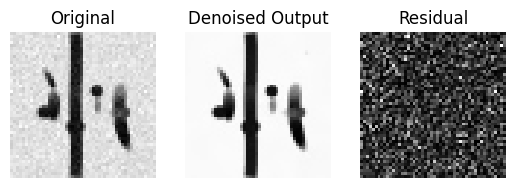

In [5]:
sli = data.shape[2] // 2
gra = data.shape[3] // 2
orig = data[:, :, sli, gra]
den = denoised_arr[:, :, sli, gra]
rms_diff = np.sqrt((orig - den) ** 2)

fig, ax = plt.subplots(1, 3)
ax[0].imshow(orig, cmap="gray", origin="lower", interpolation="none")
ax[0].set_title("Original")
ax[0].set_axis_off()
ax[1].imshow(den, cmap="gray", origin="lower", interpolation="none")
ax[1].set_title("Denoised Output")
ax[1].set_axis_off()
ax[2].imshow(rms_diff, cmap="gray", origin="lower", interpolation="none")
ax[2].set_title("Residual")
ax[2].set_axis_off()
plt.savefig("denoised_localpca.png", bbox_inches="tight")

.. rst-class:: centered small fst-italic fw-semibold

Below we show how the denoised data can be saved.


The denoised data is saved in the same format as the input data.



In [6]:
save_nifti("denoised_localpca.nii.gz", denoised_arr, affine)

### References

.. footbibliography::




.. include:: ../../links_names.inc


